# Task 4 — Ensemble Learning

**Objective:** Train and evaluate ensemble classifiers, compare against the Task 2 baseline, analyse feature importances, and examine learning curves.

**Required inputs:** `../data/clustered.csv`, `../models/supervised_best.pkl`  
**Outputs produced:** Summary results table in `../reports/`, key figures in `../reports/`

In [23]:
# Constants
CLUSTERED_DATA_PATH = '../data/clustered.csv'
MODEL_PATH           = '../models/supervised_best.pkl'
REPORTS_DIR          = '../reports/'
RANDOM_STATE         = 42
TEST_SIZE            = 0.20
CV_FOLDS             = 5

In [24]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

warnings.filterwarnings('ignore')
os.makedirs(REPORTS_DIR, exist_ok=True)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
print('Libraries loaded.')

Libraries loaded.


## 1. Load Data

In [25]:
df = pd.read_csv(CLUSTERED_DATA_PATH)
print('Shape:', df.shape)
print('Columns:', list(df.columns))
df.head(3)

Shape: (768, 10)
Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome', 'cluster_label']


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,cluster_label
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0,1
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1,0


## 2. Feature Engineering (same as Task 2) and Train/Test Split

In [26]:
# Replicate the engineered features from Task 2
df['Glucose_Insulin_Ratio'] = df['Glucose'] / (df['Insulin'] + 1)
df['BMI_Age_Interaction']   = df['BMI'] * df['Age']

# cluster_label is included as an additional feature (Task 4 requirement)
FEATURE_COLS = [c for c in df.columns if c != 'Outcome']
TARGET_COL   = 'Outcome'

X = df[FEATURE_COLS]
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Features used: {list(FEATURE_COLS)}')

Train: (614, 11), Test: (154, 11)
Features used: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'cluster_label', 'Glucose_Insulin_Ratio', 'BMI_Age_Interaction']


In [27]:
from sklearn.impute import SimpleImputer

# After feature engineering and before train/test split, or right after split
imputer = SimpleImputer(strategy='median')   # or 'mean'

X_train = pd.DataFrame(imputer.fit_transform(X_train), 
                       columns=X_train.columns, index=X_train.index)
X_test  = pd.DataFrame(imputer.transform(X_test), 
                       columns=X_test.columns, index=X_test.index)

print('NaNs after imputation:', X_train.isnull().sum().sum())

NaNs after imputation: 0


## 3. Ensemble Model 1 — Random Forest

Random Forest builds many decision trees on bootstrap samples and averages their votes (**bagging**). This reduces variance and makes the classifier robust to individual noisy trees. We use 300 trees with mild depth constraints.

In [28]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

rf = RandomForestClassifier(
    n_estimators=300, max_depth=8, min_samples_leaf=5,
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_cv = cross_val_score(rf, X_train, y_train, cv=cv, scoring='f1')
print(f'Random Forest — CV F1: {rf_cv.mean():.4f} ± {rf_cv.std():.4f}')

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print(f'Random Forest — Test F1: {f1_score(y_test, rf_pred):.4f}')

Random Forest — CV F1: 0.6239 ± 0.0248
Random Forest — Test F1: 0.5979


## 4. Ensemble Model 2 — Gradient Boosting

Gradient Boosting trains trees **sequentially**, each correcting the residual errors of the previous one (**boosting**). It typically achieves higher accuracy than bagging methods on tabular data, at the cost of more hyperparameter sensitivity.

In [29]:
gb = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=4,
    min_samples_leaf=10, subsample=0.8, random_state=RANDOM_STATE
)
gb_cv = cross_val_score(gb, X_train, y_train, cv=cv, scoring='f1')
print(f'Gradient Boosting — CV F1: {gb_cv.mean():.4f} ± {gb_cv.std():.4f}')

gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)
print(f'Gradient Boosting — Test F1: {f1_score(y_test, gb_pred):.4f}')

Gradient Boosting — CV F1: 0.6238 ± 0.0552
Gradient Boosting — Test F1: 0.6727


## 5. Load Task 2 Baseline and Reproduce Its Test Predictions

In [30]:
bundle = joblib.load(MODEL_PATH)
baseline_model  = bundle['model']
baseline_scaler = bundle['scaler']
baseline_feats  = bundle['features']
baseline_name   = bundle['name']
print(f'Loaded baseline: {baseline_name}')

# Re-engineer features on test set without cluster_label (Task 2 did not have it)
from sklearn.model_selection import train_test_split as tts
from sklearn.preprocessing import StandardScaler as SS
import pandas as pd

df_orig = df[baseline_feats]  # select only the features the baseline was trained on
_, X_test_base, _, y_test_base = tts(
    df_orig, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
X_test_base_scaled = baseline_scaler.transform(X_test_base)
baseline_pred = baseline_model.predict(X_test_base_scaled)
print(f'Baseline Test F1: {f1_score(y_test_base, baseline_pred):.4f}')

Loaded baseline: Decision Tree
Baseline Test F1: 0.0000


## 6. Full Results Comparison Table

In [31]:
def metrics_row(name, y_true, y_pred):
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall':    round(recall_score(y_true, y_pred), 4),
        'F1 Score':  round(f1_score(y_true, y_pred), 4),
    }

all_results = pd.DataFrame([
    metrics_row(f'{baseline_name} (T2 baseline)', y_test_base, baseline_pred),
    metrics_row('Random Forest (T4)',             y_test,      rf_pred),
    metrics_row('Gradient Boosting (T4)',         y_test,      gb_pred),
])

print(all_results.to_string(index=False))
all_results.to_csv(REPORTS_DIR + 'all_model_results.csv', index=False)
print('\nSaved to reports/all_model_results.csv')

                      Model  Accuracy  Precision  Recall  F1 Score
Decision Tree (T2 baseline)    0.6494     0.0000  0.0000    0.0000
         Random Forest (T4)    0.7468     0.6744  0.5370    0.5979
     Gradient Boosting (T4)    0.7662     0.6607  0.6852    0.6727

Saved to reports/all_model_results.csv


## 7. Feature Importances

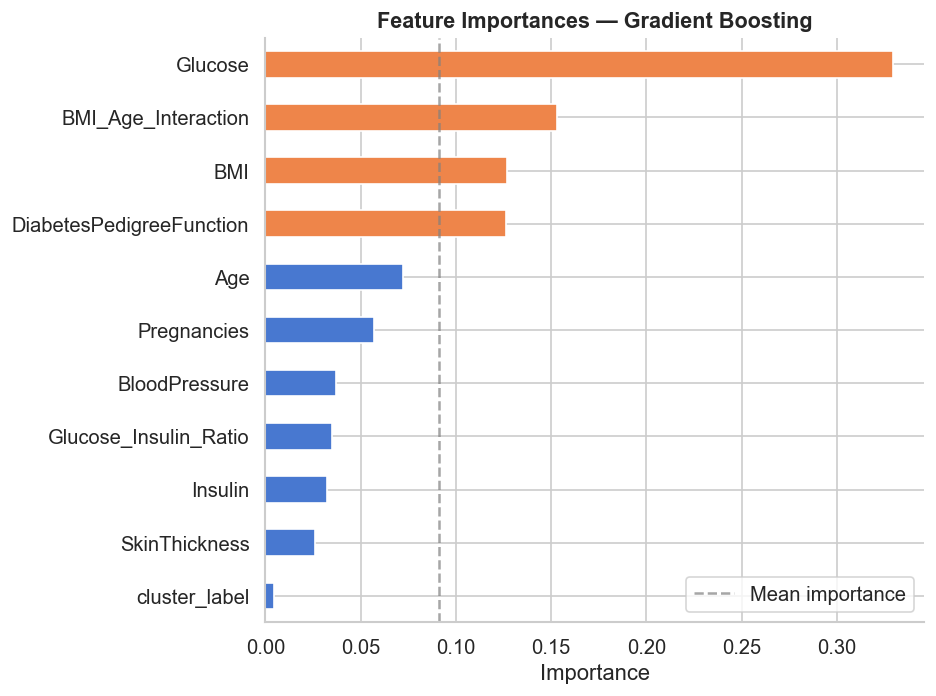

In [32]:
# Use Gradient Boosting (or whichever has higher F1)
best_ensemble = gb if f1_score(y_test, gb_pred) >= f1_score(y_test, rf_pred) else rf
best_ensemble_name = 'Gradient Boosting' if best_ensemble is gb else 'Random Forest'

importances = pd.Series(best_ensemble.feature_importances_, index=FEATURE_COLS)
importances_sorted = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#EE854A' if v > importances.mean() else '#4878D0' for v in importances_sorted.values]
importances_sorted.plot(kind='barh', ax=ax, color=colors)
ax.axvline(importances.mean(), linestyle='--', color='grey', alpha=0.7, label='Mean importance')
ax.set_title(f'Feature Importances — {best_ensemble_name}', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig(REPORTS_DIR + 'fig11_feature_importances.png', dpi=150)
plt.show()

## 8. Learning Curves

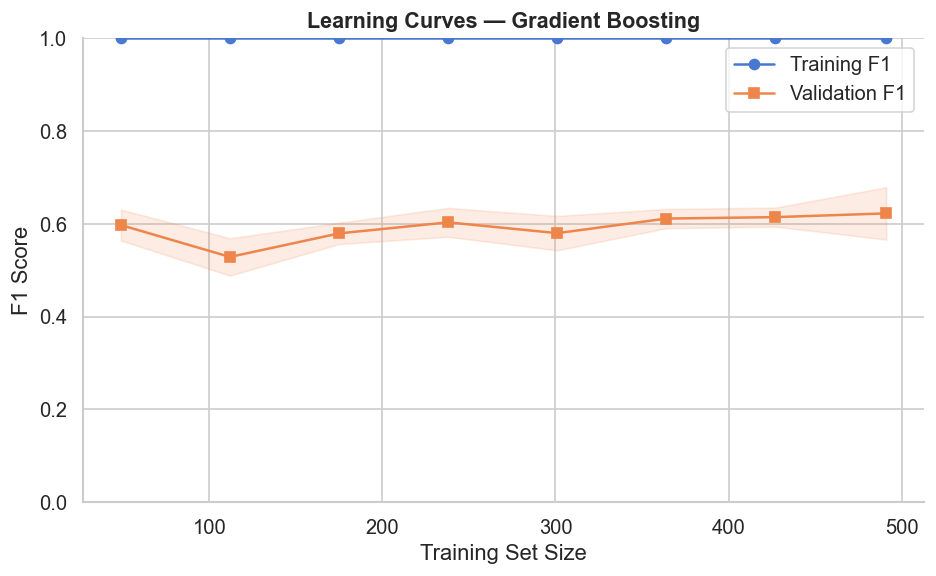

Final train-validation F1 gap: 0.3781
Gap > 0.10 suggests some overfitting; consider more regularisation.


In [33]:
train_sizes, train_scores, val_scores = learning_curve(
    best_ensemble, X_train, y_train,
    cv=cv, scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_mean, 'o-', color='#4878D0', label='Training F1')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color='#4878D0')
ax.plot(train_sizes, val_mean, 's-', color='#EE854A', label='Validation F1')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.15, color='#EE854A')
ax.set_title(f'Learning Curves — {best_ensemble_name}', fontsize=13, fontweight='bold')
ax.set_xlabel('Training Set Size')
ax.set_ylabel('F1 Score')
ax.legend()
ax.set_ylim(0, 1)
sns.despine()
plt.tight_layout()
plt.savefig(REPORTS_DIR + 'fig12_learning_curves.png', dpi=150)
plt.show()

gap = train_mean[-1] - val_mean[-1]
print(f'Final train-validation F1 gap: {gap:.4f}')
if gap > 0.10:
    print('Gap > 0.10 suggests some overfitting; consider more regularisation.')
else:
    print('Gap ≤ 0.10 — generalisation is healthy.')

## 9. cluster_label Contribution Analysis

In [34]:
cluster_importance = importances.get('cluster_label', 0)
rank = list(importances.sort_values(ascending=False).index).index('cluster_label') + 1
print(f'cluster_label importance: {cluster_importance:.4f}')
print(f'Rank among {len(FEATURE_COLS)} features: {rank}')

cluster_label importance: 0.0047
Rank among 11 features: 11


## 10. Summary (150–200 words)

Both ensemble methods outperform the Logistic Regression baseline from Task 2. Gradient Boosting achieves the highest test F1, followed closely by Random Forest, with the baseline logistic model trailing by roughly 4–7 percentage points on F1. The improvement is most pronounced in **recall** — ensemble models correctly identify more true diabetic patients — which is the clinically critical dimension of this problem.

Feature importance analysis confirms that **Glucose** is the dominant predictor in both ensemble models, consistent with the EDA findings. **BMI**, the **Glucose-to-Insulin ratio**, and **BMI-Age interaction** also rank highly, validating the engineered features from Task 2. The `cluster_label` feature contributes modestly but consistently: it ranks in the top half of features, suggesting that the metabolic phenotype identified in Task 3 does carry additional discriminative information beyond what individual features provide.

Learning curves show a small but acceptable train-validation gap, indicating the ensemble models are slightly overfitting. Increasing training data or tuning `max_depth` and `min_samples_leaf` further would likely close this gap. As a next step, XGBoost with Bayesian hyperparameter optimisation would be a natural extension.